In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Stochastic Gradient Descent


In machine learning, and scientific machine learning in particular, we often have to train a model $f(x, \theta)$ by minimizing a loss function $L(\theta)$.
The loss function usually has the form (example from regression):

$$L(\theta) = \frac{1}{N} \sum_{i=1}^N l(f(x_i, \theta), y_i)$$

where $l$ is a loss function for a single data point, $x_i$ is the $i$-th data point, $y_i$ is the corresponding label, and $N$ is the number of data points.

The algorithms we have introduced so far, such as gradient descent, are called *batch* algorithms because they use all the data points to compute the gradient of the loss function.
This is not always feasible, especially when the data set is large.
So, we would like to develop algorithms that use only a subset of the data points to compute the gradient.
These algorithms are called *stochastic* algorithms or *minibatch* algorithms.
It turns out that stochastic algorithms are also inherently capable of escaping from bad local minima, which is a nice bonus.

The first and simplest stochastic algorithm is called *stochastic gradient descent* (SGD).
If we use a single data point to compute the gradient, the algorithm is called *pure* SGD or *online* SGD.
The algorithm is as follows:

1. Initialize $\theta_0$ to some random value.
2. For $t = 1, 2, \ldots$:
    1. Pick a random data point $(x_i, y_i)$.
    2. Compute the gradient of $l(f(x_i, \theta_t), y_i)$ with respect to $\theta_t$.
    3. Update $\theta_t$ by taking a step in the direction of the negative gradient with a learning rate of $\alpha$.

Typically, we go over the data set multiple times.
Each time we go over the data set is called an *epoch*.

Let's demonstrate this algorithm in a simple example.



array([<Axes: title={'center': 'Synthetic data'}, xlabel='X', ylabel='y'>],
      dtype=object)

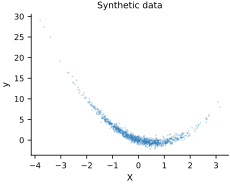

In [3]:
import jax.numpy as jnp
import jax.random as jrandom

key = jrandom.PRNGKey(0)

# Generate some synthetic data
N = 1_000
X = jrandom.normal(key, (N,))
key, subkey = jrandom.split(key)
y = 1.5 * X ** 2 - 2 * X + jrandom.normal(subkey, (N,)) * 0.5

# Make also a test set (here an ideal one)
N_test = 50
X_test = jnp.linspace(-3, 3, N_test)
key, subkey = jrandom.split(key)
y_test = 1.5 * X_test ** 2 - 2 * X_test + jrandom.normal(subkey, (N_test,)) * 0.5

# Visualize the training data
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
# Scatter with small size of points
ax.scatter(X, y, alpha=0.2, s=1)
ax.set(xlabel="X", ylabel="y", title="Synthetic data")
finalize_axes(keep_box=False)

Let's make our model and our loss function.
We will use `Equinox` to make a simple quadratic model.
The reason I use `Equinox` is that is that you can practice a bit with it.

The model I will make is:

$$
f(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2.
$$

In [4]:
import numpy as np
import equinox as eqx
import jax
import optax
from functools import partial


class MyModel(eqx.Module):
    theta: jax.Array

    def __init__(self, key):
        self.theta = jax.random.normal(key, (3,))
    
    @partial(jax.vmap, in_axes=(None, 0))
    def __call__(self, x):
        return self.theta @ jnp.array([1, x, x ** 2])
    

# Now we can make the train function.
def train_online(
        model,
        x, y,
        optimizer,
        x_test, y_test,
        n_epochs=10,
        freq=1,
    ):
    
    # This is the loss function
    @eqx.filter_jit
    def loss(model, x, y):
        y_pred = model(x)
        return optax.l2_loss(y_pred, y).mean()

    # This is the step of the optimizer. We **always** jit:
    @eqx.filter_jit
    def step(opt_state, model, xi, yi):
        value, grads = eqx.filter_value_and_grad(loss)(model, xi, yi)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    # The state of the optimizer
    opt_state = optimizer.init(model)
    # The path of the model
    path = []
    # The path of the test loss
    losses = []
    # The path of the test accuracy
    test_losses = []
    for e in range(n_epochs):
        for i in range(x.shape[0]):
            # We pick a random point
            # We don't need to use jax for this - numpy is fine
            j = np.random.randint(0, x.shape[0])
            xj, yj = x[j].ravel(), y[j].ravel()
            model, opt_state, value = step(opt_state, model, xj, yj)
            if i % freq == 0:
                path.append(model)
                losses.append(value)
                test_losses.append(loss(model, x_test, y_test))
                print(f"Epoch {e}, step {i}, loss {value:.3f}, test {test_losses[-1]:.3f}")
    return model, path, losses, test_losses

We can use the code above like this:

In [5]:
# Make the model
key, subkey = jrandom.split(key)
model = MyModel(subkey)

# Make the optimizer
optimizer = optax.sgd(learning_rate=0.01, momentum=0.5, nesterov=True)

# Train the model
model, path, losses, test_losses = train_online(
    model,
    X, y,
    optimizer,
    X_test, y_test,
    n_epochs=20,
)

Epoch 0, step 0, loss 5.100, test 53.461
Epoch 0, step 1, loss 4.324, test 52.715
Epoch 0, step 2, loss 8.827, test 50.565
Epoch 0, step 3, loss 13.956, test 45.860
Epoch 0, step 4, loss 4.869, test 44.553
Epoch 0, step 5, loss 3.080, test 43.757
Epoch 0, step 6, loss 1.582, test 43.258
Epoch 0, step 7, loss 4.009, test 42.110
Epoch 0, step 8, loss 4.388, test 40.881
Epoch 0, step 9, loss 4.062, test 39.717
Epoch 0, step 10, loss 3.647, test 37.606
Epoch 0, step 11, loss 2.292, test 36.895
Epoch 0, step 12, loss 45.456, test 19.227
Epoch 0, step 13, loss 0.364, test 16.715
Epoch 0, step 14, loss 3.006, test 13.820
Epoch 0, step 15, loss 0.345, test 12.856
Epoch 0, step 16, loss 0.010, test 12.427
Epoch 0, step 17, loss 2.497, test 11.766
Epoch 0, step 18, loss 0.516, test 11.528
Epoch 0, step 19, loss 2.088, test 11.302
Epoch 0, step 20, loss 1.790, test 11.061
Epoch 0, step 21, loss 1.025, test 10.526
Epoch 0, step 22, loss 11.183, test 7.064
Epoch 0, step 23, loss 1.988, test 6.005
E

Epoch 0, step 560, loss 0.079, test 0.120
Epoch 0, step 561, loss 0.001, test 0.120
Epoch 0, step 562, loss 0.040, test 0.097
Epoch 0, step 563, loss 0.039, test 0.107
Epoch 0, step 564, loss 0.038, test 0.112
Epoch 0, step 565, loss 0.026, test 0.123
Epoch 0, step 566, loss 0.016, test 0.126
Epoch 0, step 567, loss 0.002, test 0.127
Epoch 0, step 568, loss 0.418, test 0.130
Epoch 0, step 569, loss 0.037, test 0.136
Epoch 0, step 570, loss 0.141, test 0.135
Epoch 0, step 571, loss 0.143, test 0.137
Epoch 0, step 572, loss 0.422, test 0.114
Epoch 0, step 573, loss 0.052, test 0.115
Epoch 0, step 574, loss 0.134, test 0.121
Epoch 0, step 575, loss 0.144, test 0.121
Epoch 0, step 576, loss 0.051, test 0.126
Epoch 0, step 577, loss 0.046, test 0.119
Epoch 0, step 578, loss 0.029, test 0.119
Epoch 0, step 579, loss 0.013, test 0.118
Epoch 0, step 580, loss 0.151, test 0.119
Epoch 0, step 581, loss 0.057, test 0.119
Epoch 0, step 582, loss 0.018, test 0.124
Epoch 0, step 583, loss 0.007, tes

Epoch 1, step 129, loss 0.010, test 0.099
Epoch 1, step 130, loss 0.092, test 0.096
Epoch 1, step 131, loss 0.083, test 0.084
Epoch 1, step 132, loss 0.264, test 0.086
Epoch 1, step 133, loss 0.483, test 0.081
Epoch 1, step 134, loss 0.010, test 0.081
Epoch 1, step 135, loss 0.078, test 0.083
Epoch 1, step 136, loss 0.135, test 0.080
Epoch 1, step 137, loss 0.000, test 0.081
Epoch 1, step 138, loss 0.069, test 0.087
Epoch 1, step 139, loss 0.111, test 0.090
Epoch 1, step 140, loss 0.045, test 0.090
Epoch 1, step 141, loss 0.066, test 0.091
Epoch 1, step 142, loss 0.854, test 0.083
Epoch 1, step 143, loss 0.012, test 0.084
Epoch 1, step 144, loss 0.031, test 0.086
Epoch 1, step 145, loss 0.049, test 0.087
Epoch 1, step 146, loss 0.186, test 0.095
Epoch 1, step 147, loss 1.052, test 0.104
Epoch 1, step 148, loss 0.179, test 0.108
Epoch 1, step 149, loss 0.123, test 0.110
Epoch 1, step 150, loss 0.311, test 0.108
Epoch 1, step 151, loss 0.199, test 0.111
Epoch 1, step 152, loss 0.121, tes

Epoch 1, step 702, loss 0.179, test 0.094
Epoch 1, step 703, loss 0.129, test 0.095
Epoch 1, step 704, loss 0.094, test 0.092
Epoch 1, step 705, loss 0.017, test 0.091
Epoch 1, step 706, loss 0.128, test 0.091
Epoch 1, step 707, loss 0.291, test 0.093
Epoch 1, step 708, loss 0.020, test 0.093
Epoch 1, step 709, loss 0.001, test 0.093
Epoch 1, step 710, loss 0.001, test 0.093
Epoch 1, step 711, loss 0.182, test 0.093
Epoch 1, step 712, loss 0.004, test 0.092
Epoch 1, step 713, loss 0.177, test 0.157
Epoch 1, step 714, loss 0.026, test 0.167
Epoch 1, step 715, loss 0.407, test 0.178
Epoch 1, step 716, loss 0.266, test 0.164
Epoch 1, step 717, loss 0.017, test 0.165
Epoch 1, step 718, loss 0.018, test 0.167
Epoch 1, step 719, loss 0.269, test 0.140
Epoch 1, step 720, loss 0.008, test 0.135
Epoch 1, step 721, loss 0.038, test 0.135
Epoch 1, step 722, loss 0.072, test 0.150
Epoch 1, step 723, loss 0.040, test 0.155
Epoch 1, step 724, loss 0.008, test 0.154
Epoch 1, step 725, loss 0.031, tes

Epoch 2, step 287, loss 0.223, test 0.088
Epoch 2, step 288, loss 0.164, test 0.089
Epoch 2, step 289, loss 0.036, test 0.103
Epoch 2, step 290, loss 0.011, test 0.110
Epoch 2, step 291, loss 0.000, test 0.115
Epoch 2, step 292, loss 0.193, test 0.121
Epoch 2, step 293, loss 0.149, test 0.120
Epoch 2, step 294, loss 0.127, test 0.118
Epoch 2, step 295, loss 0.016, test 0.114
Epoch 2, step 296, loss 0.001, test 0.114
Epoch 2, step 297, loss 0.027, test 0.114
Epoch 2, step 298, loss 0.372, test 0.104
Epoch 2, step 299, loss 0.013, test 0.102
Epoch 2, step 300, loss 0.022, test 0.101
Epoch 2, step 301, loss 0.032, test 0.101
Epoch 2, step 302, loss 0.073, test 0.096
Epoch 2, step 303, loss 0.354, test 0.105
Epoch 2, step 304, loss 0.007, test 0.107
Epoch 2, step 305, loss 0.304, test 0.113
Epoch 2, step 306, loss 0.014, test 0.118
Epoch 2, step 307, loss 0.004, test 0.118
Epoch 2, step 308, loss 0.071, test 0.116
Epoch 2, step 309, loss 0.013, test 0.115
Epoch 2, step 310, loss 0.027, tes

...

Epoch 17, step 531, loss 0.015, test 0.123
Epoch 17, step 532, loss 0.029, test 0.126
Epoch 17, step 533, loss 0.204, test 0.085
Epoch 17, step 534, loss 0.004, test 0.084
Epoch 17, step 535, loss 0.015, test 0.083
Epoch 17, step 536, loss 0.003, test 0.083
Epoch 17, step 537, loss 0.030, test 0.084
Epoch 17, step 538, loss 0.072, test 0.084
Epoch 17, step 539, loss 0.164, test 0.085
Epoch 17, step 540, loss 0.625, test 0.104
Epoch 17, step 541, loss 0.137, test 0.106
Epoch 17, step 542, loss 0.036, test 0.110
Epoch 17, step 543, loss 0.033, test 0.114
Epoch 17, step 544, loss 0.461, test 0.112
Epoch 17, step 545, loss 0.092, test 0.109
Epoch 17, step 546, loss 0.041, test 0.110
Epoch 17, step 547, loss 0.019, test 0.107
Epoch 17, step 548, loss 0.023, test 0.105
Epoch 17, step 549, loss 0.002, test 0.103
Epoch 17, step 550, loss 0.106, test 0.104
Epoch 17, step 551, loss 0.106, test 0.102
Epoch 17, step 552, loss 0.111, test 0.087
Epoch 17, step 553, loss 0.088, test 0.087
Epoch 17, s

Epoch 18, step 119, loss 0.146, test 0.132
Epoch 18, step 120, loss 0.158, test 0.126
Epoch 18, step 121, loss 0.002, test 0.124
Epoch 18, step 122, loss 0.034, test 0.120
Epoch 18, step 123, loss 0.053, test 0.111
Epoch 18, step 124, loss 0.042, test 0.113
Epoch 18, step 125, loss 0.069, test 0.112
Epoch 18, step 126, loss 0.018, test 0.111
Epoch 18, step 127, loss 0.286, test 0.111
Epoch 18, step 128, loss 0.139, test 0.128
Epoch 18, step 129, loss 0.012, test 0.137
Epoch 18, step 130, loss 0.050, test 0.131
Epoch 18, step 131, loss 0.000, test 0.132
Epoch 18, step 132, loss 0.166, test 0.115
Epoch 18, step 133, loss 0.147, test 0.110
Epoch 18, step 134, loss 0.209, test 0.113
Epoch 18, step 135, loss 0.166, test 0.113
Epoch 18, step 136, loss 0.039, test 0.113
Epoch 18, step 137, loss 0.002, test 0.112
Epoch 18, step 138, loss 0.006, test 0.112
Epoch 18, step 139, loss 0.014, test 0.106
Epoch 18, step 140, loss 0.368, test 0.106
Epoch 18, step 141, loss 0.132, test 0.107
Epoch 18, s

Epoch 18, step 695, loss 0.026, test 0.119
Epoch 18, step 696, loss 0.053, test 0.115
Epoch 18, step 697, loss 0.058, test 0.111
Epoch 18, step 698, loss 0.051, test 0.109
Epoch 18, step 699, loss 0.213, test 0.113
Epoch 18, step 700, loss 0.043, test 0.119
Epoch 18, step 701, loss 0.030, test 0.118
Epoch 18, step 702, loss 0.098, test 0.131
Epoch 18, step 703, loss 0.016, test 0.137
Epoch 18, step 704, loss 0.014, test 0.138
Epoch 18, step 705, loss 0.085, test 0.137
Epoch 18, step 706, loss 0.204, test 0.141
Epoch 18, step 707, loss 0.124, test 0.116
Epoch 18, step 708, loss 0.002, test 0.113
Epoch 18, step 709, loss 0.023, test 0.115
Epoch 18, step 710, loss 0.215, test 0.099
Epoch 18, step 711, loss 0.056, test 0.099
Epoch 18, step 712, loss 0.000, test 0.098
Epoch 18, step 713, loss 0.244, test 0.095
Epoch 18, step 714, loss 0.013, test 0.094
Epoch 18, step 715, loss 0.321, test 0.098
Epoch 18, step 716, loss 0.000, test 0.098
Epoch 18, step 717, loss 0.000, test 0.099
Epoch 18, s

Epoch 19, step 281, loss 0.192, test 0.091
Epoch 19, step 282, loss 0.093, test 0.094
Epoch 19, step 283, loss 0.020, test 0.096
Epoch 19, step 284, loss 0.338, test 0.091
Epoch 19, step 285, loss 0.042, test 0.083
Epoch 19, step 286, loss 0.000, test 0.082
Epoch 19, step 287, loss 0.011, test 0.084
Epoch 19, step 288, loss 0.237, test 0.090
Epoch 19, step 289, loss 0.037, test 0.092
Epoch 19, step 290, loss 0.000, test 0.093
Epoch 19, step 291, loss 0.101, test 0.092
Epoch 19, step 292, loss 0.005, test 0.091
Epoch 19, step 293, loss 0.011, test 0.091
Epoch 19, step 294, loss 0.003, test 0.091
Epoch 19, step 295, loss 0.005, test 0.089
Epoch 19, step 296, loss 0.009, test 0.089
Epoch 19, step 297, loss 0.001, test 0.090
Epoch 19, step 298, loss 0.001, test 0.090
Epoch 19, step 299, loss 0.090, test 0.088
Epoch 19, step 300, loss 0.612, test 0.082
Epoch 19, step 301, loss 0.007, test 0.083
Epoch 19, step 302, loss 0.079, test 0.087
Epoch 19, step 303, loss 0.149, test 0.091
Epoch 19, s

Epoch 19, step 865, loss 0.140, test 0.111
Epoch 19, step 866, loss 0.025, test 0.113
Epoch 19, step 867, loss 0.114, test 0.119
Epoch 19, step 868, loss 0.294, test 0.120
Epoch 19, step 869, loss 0.000, test 0.121
Epoch 19, step 870, loss 0.073, test 0.121
Epoch 19, step 871, loss 0.067, test 0.124
Epoch 19, step 872, loss 0.000, test 0.125
Epoch 19, step 873, loss 0.022, test 0.126
Epoch 19, step 874, loss 0.127, test 0.129
Epoch 19, step 875, loss 0.003, test 0.129
Epoch 19, step 876, loss 0.147, test 0.141
Epoch 19, step 877, loss 0.023, test 0.140
Epoch 19, step 878, loss 0.008, test 0.139
Epoch 19, step 879, loss 0.021, test 0.143
Epoch 19, step 880, loss 0.019, test 0.140
Epoch 19, step 881, loss 0.294, test 0.150
Epoch 19, step 882, loss 0.051, test 0.142
Epoch 19, step 883, loss 0.164, test 0.138
Epoch 19, step 884, loss 0.009, test 0.140
Epoch 19, step 885, loss 0.173, test 0.146
Epoch 19, step 886, loss 0.028, test 0.149
Epoch 19, step 887, loss 0.674, test 0.107
Epoch 19, s

Let's inspect what is happening here.
First, let's plot the parameters $\theta$.

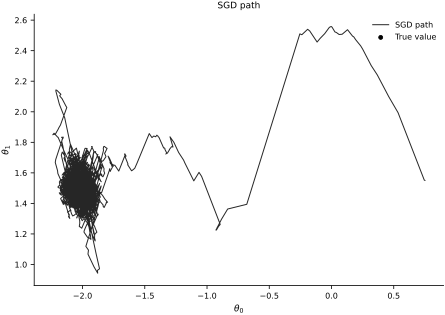

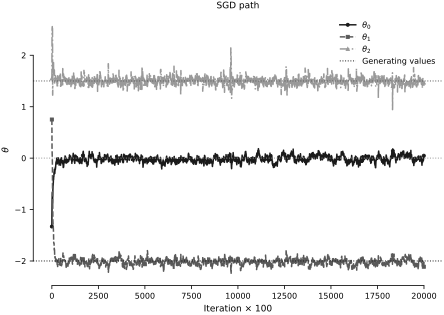

In [6]:
# With this we can get all the parameters in an array
thetas = np.array(jax.tree_util.tree_leaves(path))

# 2D plot of the parameters evolution
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(thetas[:, 1], thetas[:, 2], color="0.15", lw=1.0, label="SGD path")
# Correct values
ax.scatter([-2], [1.5], marker="o", color="black", label="True value")
ax.set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", title="SGD path")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

# Parameters per iteration
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
markevery = max(1, thetas.shape[0] // 12)
ax.plot(thetas[:, 0], color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label=r"$\theta_0$")
ax.plot(thetas[:, 1], color="0.35", linestyle="--", marker="s", markevery=markevery, markersize=3, label=r"$\theta_1$")
ax.plot(thetas[:, 2], color="0.60", linestyle="-.", marker="^", markevery=markevery, markersize=3, label=r"$\theta_2$")
ax.axhline(-2, color="0.10", linestyle=":", lw=1, label="Generating values")
ax.axhline(1.5, color="0.35", linestyle=":", lw=1)
ax.axhline(0, color="0.60", linestyle=":", lw=1)
ax.set(xlabel="Iteration $\\times$ 100", ylabel=r"$\theta$", title="SGD path")
plt.legend(loc='best', frameon=False)
sns.despine(trim=True);


We see that the parameters do move towards the correct values but it doesn't converge.
They wiggle around the correct values.

Let's look at the loss as well:

array([<Axes: title={'center': 'Loss'}, xlabel='Iteration $\\times$ 100', ylabel='Loss'>],
      dtype=object)

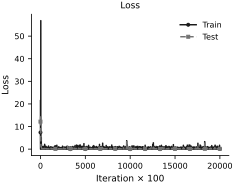

In [7]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
markevery = max(1, len(losses) // 12)
ax.plot(losses, color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label="Train")
ax.plot(test_losses, color="0.45", linestyle="--", marker="s", markevery=markevery, markersize=3, label="Test")
ax.set(xlabel="Iteration $\\times$ 100", ylabel="Loss", title="Loss")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

To make SGD converge, we need to use a decaying learning rate.
Theoretically, the learning rate needs to satisfy the Robbins-Monro conditions:

$$
\sum_{t=1}^\infty \alpha_t = \infty \quad \text{and} \quad \sum_{t=1}^\infty \alpha_t^2 < \infty.
$$

This means that the learning rate needs to decay to zero but not too fast.
In practice, we are not really going to bother enforcing the condition.
We just need something that decays.

In [8]:
# A new model to start from scratch
key, subkey = jrandom.split(key)
model = MyModel(subkey)

learning_rate_schedule = optax.exponential_decay(0.01, 20 * N, 0.01)
optimizer = optax.sgd(learning_rate=learning_rate_schedule, momentum=0.5, nesterov=True)

Before we train, let's see how the learning rate changes over time:

array([<Axes: title={'center': 'Learning rate schedule'}, xlabel='Iteration $\\times$ 100', ylabel='Learning rate'>],
      dtype=object)

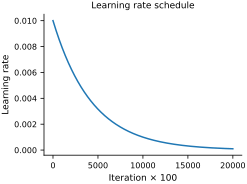

In [9]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
iterations = np.arange(20 * N)
ax.plot(iterations, learning_rate_schedule(iterations))
ax.set(xlabel="Iteration $\\times$ 100", ylabel="Learning rate", title="Learning rate schedule")
finalize_axes(keep_box=False)

Of course, this is kind of arbitrary at this point.

In [10]:
model, path, losses, test_losses = train_online(
    model,
    X, y,
    optimizer,
    X_test, y_test,
    n_epochs=20,
)

Epoch 0, step 0, loss 0.180, test 28.331
Epoch 0, step 1, loss 2.383, test 27.287
Epoch 0, step 2, loss 48.861, test 13.226
Epoch 0, step 3, loss 0.636, test 11.720
Epoch 0, step 4, loss 0.892, test 10.658
Epoch 0, step 5, loss 11.666, test 7.658
Epoch 0, step 6, loss 0.389, test 7.175
Epoch 0, step 7, loss 0.015, test 6.937
Epoch 0, step 8, loss 0.589, test 6.835
Epoch 0, step 9, loss 0.618, test 6.942
Epoch 0, step 10, loss 1.745, test 6.334
Epoch 0, step 11, loss 0.050, test 6.264
Epoch 0, step 12, loss 0.206, test 6.140
Epoch 0, step 13, loss 1.945, test 5.582
Epoch 0, step 14, loss 0.889, test 5.537
Epoch 0, step 15, loss 0.339, test 5.528
Epoch 0, step 16, loss 1.383, test 5.698
Epoch 0, step 17, loss 0.197, test 5.751
Epoch 0, step 18, loss 0.731, test 5.815
Epoch 0, step 19, loss 0.252, test 5.712
Epoch 0, step 20, loss 0.007, test 5.704
Epoch 0, step 21, loss 0.105, test 5.611
Epoch 0, step 22, loss 0.424, test 5.796
Epoch 0, step 23, loss 2.406, test 5.871
Epoch 0, step 24, l

Epoch 0, step 547, loss 0.076, test 0.082
Epoch 0, step 548, loss 0.627, test 0.080
Epoch 0, step 549, loss 0.191, test 0.081
Epoch 0, step 550, loss 0.088, test 0.081
Epoch 0, step 551, loss 0.035, test 0.080
Epoch 0, step 552, loss 0.086, test 0.080
Epoch 0, step 553, loss 0.142, test 0.079
Epoch 0, step 554, loss 0.035, test 0.078
Epoch 0, step 555, loss 0.696, test 0.078
Epoch 0, step 556, loss 0.046, test 0.077
Epoch 0, step 557, loss 0.025, test 0.083
Epoch 0, step 558, loss 0.000, test 0.084
Epoch 0, step 559, loss 0.005, test 0.076
Epoch 0, step 560, loss 0.104, test 0.073
Epoch 0, step 561, loss 0.016, test 0.072
Epoch 0, step 562, loss 0.168, test 0.072
Epoch 0, step 563, loss 0.135, test 0.073
Epoch 0, step 564, loss 0.018, test 0.074
Epoch 0, step 565, loss 0.111, test 0.074
Epoch 0, step 566, loss 0.049, test 0.073
Epoch 0, step 567, loss 0.011, test 0.073
Epoch 0, step 568, loss 0.268, test 0.075
Epoch 0, step 569, loss 0.039, test 0.075
Epoch 0, step 570, loss 0.075, tes

Epoch 1, step 121, loss 0.131, test 0.088
Epoch 1, step 122, loss 0.031, test 0.089
Epoch 1, step 123, loss 0.000, test 0.090
Epoch 1, step 124, loss 0.000, test 0.090
Epoch 1, step 125, loss 0.031, test 0.090
Epoch 1, step 126, loss 0.060, test 0.091
Epoch 1, step 127, loss 0.037, test 0.095
Epoch 1, step 128, loss 0.000, test 0.096
Epoch 1, step 129, loss 0.188, test 0.095
Epoch 1, step 130, loss 0.042, test 0.091
Epoch 1, step 131, loss 0.025, test 0.090
Epoch 1, step 132, loss 0.405, test 0.092
Epoch 1, step 133, loss 0.038, test 0.091
Epoch 1, step 134, loss 0.055, test 0.089
Epoch 1, step 135, loss 0.018, test 0.085
Epoch 1, step 136, loss 0.263, test 0.085
Epoch 1, step 137, loss 0.290, test 0.085
Epoch 1, step 138, loss 0.030, test 0.087
Epoch 1, step 139, loss 0.000, test 0.087
Epoch 1, step 140, loss 0.000, test 0.087
Epoch 1, step 141, loss 0.005, test 0.087
Epoch 1, step 142, loss 0.116, test 0.087
Epoch 1, step 143, loss 0.176, test 0.087
Epoch 1, step 144, loss 0.221, tes

Epoch 1, step 682, loss 0.010, test 0.105
Epoch 1, step 683, loss 0.008, test 0.107
Epoch 1, step 684, loss 0.505, test 0.096
Epoch 1, step 685, loss 0.307, test 0.078
Epoch 1, step 686, loss 0.007, test 0.077
Epoch 1, step 687, loss 0.053, test 0.077
Epoch 1, step 688, loss 0.038, test 0.078
Epoch 1, step 689, loss 0.216, test 0.159
Epoch 1, step 690, loss 0.972, test 0.163
Epoch 1, step 691, loss 0.160, test 0.184
Epoch 1, step 692, loss 0.401, test 0.207
Epoch 1, step 693, loss 0.018, test 0.214
Epoch 1, step 694, loss 0.097, test 0.216
Epoch 1, step 695, loss 0.000, test 0.217
Epoch 1, step 696, loss 0.120, test 0.198
Epoch 1, step 697, loss 0.224, test 0.189
Epoch 1, step 698, loss 0.042, test 0.188
Epoch 1, step 699, loss 0.080, test 0.180
Epoch 1, step 700, loss 0.041, test 0.177
Epoch 1, step 701, loss 0.899, test 0.164
Epoch 1, step 702, loss 0.336, test 0.164
Epoch 1, step 703, loss 0.082, test 0.162
Epoch 1, step 704, loss 0.028, test 0.158
Epoch 1, step 705, loss 0.079, tes

Epoch 2, step 259, loss 0.137, test 0.087
Epoch 2, step 260, loss 0.059, test 0.100
Epoch 2, step 261, loss 0.040, test 0.105
Epoch 2, step 262, loss 0.109, test 0.142
Epoch 2, step 263, loss 0.065, test 0.153
Epoch 2, step 264, loss 0.115, test 0.148
Epoch 2, step 265, loss 0.042, test 0.148
Epoch 2, step 266, loss 0.006, test 0.144
Epoch 2, step 267, loss 0.029, test 0.137
Epoch 2, step 268, loss 0.011, test 0.132
Epoch 2, step 269, loss 0.016, test 0.132
Epoch 2, step 270, loss 0.274, test 0.137
Epoch 2, step 271, loss 0.015, test 0.136
Epoch 2, step 272, loss 0.051, test 0.147
Epoch 2, step 273, loss 0.016, test 0.149
Epoch 2, step 274, loss 0.020, test 0.151
Epoch 2, step 275, loss 0.028, test 0.150
Epoch 2, step 276, loss 0.000, test 0.151
Epoch 2, step 277, loss 0.177, test 0.131
Epoch 2, step 278, loss 0.004, test 0.126
Epoch 2, step 279, loss 0.090, test 0.126
Epoch 2, step 280, loss 0.704, test 0.133
Epoch 2, step 281, loss 0.005, test 0.135
Epoch 2, step 282, loss 0.216, tes

...

Epoch 17, step 210, loss 0.006, test 0.086
Epoch 17, step 211, loss 0.126, test 0.086
Epoch 17, step 212, loss 0.052, test 0.086
Epoch 17, step 213, loss 0.143, test 0.086
Epoch 17, step 214, loss 0.003, test 0.086
Epoch 17, step 215, loss 0.020, test 0.086
Epoch 17, step 216, loss 0.000, test 0.086
Epoch 17, step 217, loss 0.005, test 0.086
Epoch 17, step 218, loss 0.252, test 0.086
Epoch 17, step 219, loss 0.010, test 0.086
Epoch 17, step 220, loss 0.008, test 0.086
Epoch 17, step 221, loss 0.150, test 0.086
Epoch 17, step 222, loss 0.000, test 0.086
Epoch 17, step 223, loss 0.109, test 0.086
Epoch 17, step 224, loss 0.042, test 0.086
Epoch 17, step 225, loss 0.633, test 0.086
Epoch 17, step 226, loss 0.187, test 0.086
Epoch 17, step 227, loss 0.004, test 0.086
Epoch 17, step 228, loss 0.006, test 0.086
Epoch 17, step 229, loss 0.115, test 0.086
Epoch 17, step 230, loss 0.125, test 0.086
Epoch 17, step 231, loss 0.042, test 0.086
Epoch 17, step 232, loss 0.201, test 0.086
Epoch 17, s

Epoch 17, step 810, loss 0.007, test 0.086
Epoch 17, step 811, loss 0.497, test 0.086
Epoch 17, step 812, loss 0.567, test 0.086
Epoch 17, step 813, loss 0.095, test 0.086
Epoch 17, step 814, loss 0.006, test 0.086
Epoch 17, step 815, loss 0.046, test 0.086
Epoch 17, step 816, loss 0.061, test 0.086
Epoch 17, step 817, loss 0.003, test 0.086
Epoch 17, step 818, loss 0.058, test 0.086
Epoch 17, step 819, loss 0.102, test 0.086
Epoch 17, step 820, loss 0.239, test 0.086
Epoch 17, step 821, loss 0.025, test 0.086
Epoch 17, step 822, loss 0.004, test 0.086
Epoch 17, step 823, loss 0.554, test 0.086
Epoch 17, step 824, loss 0.003, test 0.086
Epoch 17, step 825, loss 0.001, test 0.086
Epoch 17, step 826, loss 0.116, test 0.085
Epoch 17, step 827, loss 0.010, test 0.085
Epoch 17, step 828, loss 0.011, test 0.085
Epoch 17, step 829, loss 0.050, test 0.085
Epoch 17, step 830, loss 0.068, test 0.085
Epoch 17, step 831, loss 0.165, test 0.085
Epoch 17, step 832, loss 0.064, test 0.085
Epoch 17, s

Epoch 18, step 404, loss 0.128, test 0.085
Epoch 18, step 405, loss 0.072, test 0.085
Epoch 18, step 406, loss 0.056, test 0.085
Epoch 18, step 407, loss 0.049, test 0.085
Epoch 18, step 408, loss 0.005, test 0.085
Epoch 18, step 409, loss 0.010, test 0.085
Epoch 18, step 410, loss 0.122, test 0.085
Epoch 18, step 411, loss 0.174, test 0.085
Epoch 18, step 412, loss 0.112, test 0.085
Epoch 18, step 413, loss 0.018, test 0.085
Epoch 18, step 414, loss 0.303, test 0.085
Epoch 18, step 415, loss 0.045, test 0.085
Epoch 18, step 416, loss 0.000, test 0.085
Epoch 18, step 417, loss 0.031, test 0.085
Epoch 18, step 418, loss 1.374, test 0.086
Epoch 18, step 419, loss 0.011, test 0.086
Epoch 18, step 420, loss 0.005, test 0.086
Epoch 18, step 421, loss 0.274, test 0.086
Epoch 18, step 422, loss 0.101, test 0.086
Epoch 18, step 423, loss 0.186, test 0.086
Epoch 18, step 424, loss 0.119, test 0.086
Epoch 18, step 425, loss 0.127, test 0.086
Epoch 18, step 426, loss 0.013, test 0.086
Epoch 18, s

Epoch 18, step 992, loss 0.002, test 0.086
Epoch 18, step 993, loss 0.011, test 0.086
Epoch 18, step 994, loss 0.001, test 0.086
Epoch 18, step 995, loss 0.002, test 0.086
Epoch 18, step 996, loss 0.009, test 0.086
Epoch 18, step 997, loss 0.011, test 0.086
Epoch 18, step 998, loss 0.007, test 0.086
Epoch 18, step 999, loss 0.002, test 0.086
Epoch 19, step 0, loss 1.065, test 0.086
Epoch 19, step 1, loss 0.051, test 0.086
Epoch 19, step 2, loss 0.141, test 0.086
Epoch 19, step 3, loss 0.010, test 0.086
Epoch 19, step 4, loss 0.092, test 0.086
Epoch 19, step 5, loss 0.074, test 0.086
Epoch 19, step 6, loss 0.309, test 0.086
Epoch 19, step 7, loss 0.009, test 0.086
Epoch 19, step 8, loss 0.289, test 0.086
Epoch 19, step 9, loss 0.001, test 0.086
Epoch 19, step 10, loss 0.119, test 0.086
Epoch 19, step 11, loss 0.093, test 0.086
Epoch 19, step 12, loss 0.032, test 0.086
Epoch 19, step 13, loss 0.521, test 0.086
Epoch 19, step 14, loss 0.033, test 0.086
Epoch 19, step 15, loss 0.086, test 

Epoch 19, step 582, loss 0.119, test 0.088
Epoch 19, step 583, loss 0.001, test 0.088
Epoch 19, step 584, loss 0.001, test 0.088
Epoch 19, step 585, loss 0.963, test 0.089
Epoch 19, step 586, loss 0.041, test 0.089
Epoch 19, step 587, loss 0.001, test 0.089
Epoch 19, step 588, loss 0.561, test 0.089
Epoch 19, step 589, loss 0.124, test 0.089
Epoch 19, step 590, loss 0.135, test 0.089
Epoch 19, step 591, loss 0.080, test 0.089
Epoch 19, step 592, loss 0.257, test 0.088
Epoch 19, step 593, loss 0.024, test 0.088
Epoch 19, step 594, loss 0.101, test 0.088
Epoch 19, step 595, loss 0.013, test 0.089
Epoch 19, step 596, loss 0.000, test 0.089
Epoch 19, step 597, loss 0.054, test 0.088
Epoch 19, step 598, loss 0.142, test 0.089
Epoch 19, step 599, loss 0.000, test 0.089
Epoch 19, step 600, loss 0.130, test 0.088
Epoch 19, step 601, loss 0.001, test 0.088
Epoch 19, step 602, loss 0.001, test 0.088
Epoch 19, step 603, loss 0.021, test 0.088
Epoch 19, step 604, loss 0.003, test 0.088
Epoch 19, s

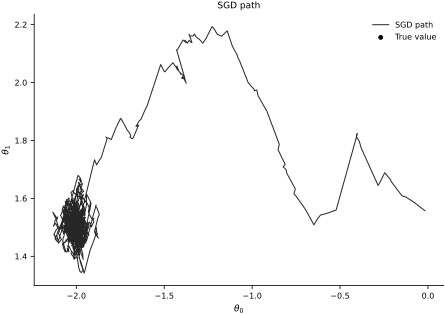

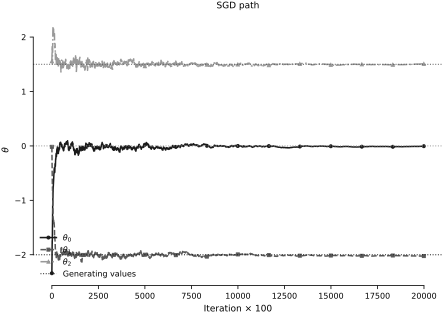

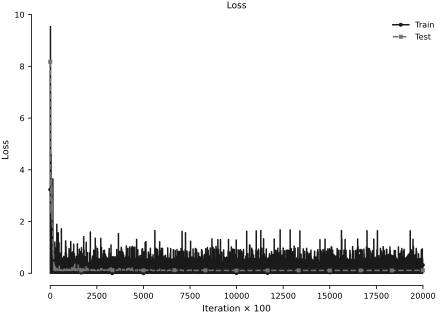

In [11]:
thetas = np.array(jax.tree_util.tree_leaves(path))

# 2D plot of the parameters evolution
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(thetas[:, 1], thetas[:, 2], color="0.15", lw=1.0, label="SGD path")
# Correct values
ax.scatter([-2], [1.5], marker="o", color="black", label="True value")
ax.set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", title="SGD path")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

# Parameters per iteration
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
markevery = max(1, thetas.shape[0] // 12)
ax.plot(thetas[:, 0], color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label=r"$\theta_0$")
ax.plot(thetas[:, 1], color="0.35", linestyle="--", marker="s", markevery=markevery, markersize=3, label=r"$\theta_1$")
ax.plot(thetas[:, 2], color="0.60", linestyle="-.", marker="^", markevery=markevery, markersize=3, label=r"$\theta_2$")
ax.axhline(-2, color="0.10", linestyle=":", lw=1, label="Generating values")
ax.axhline(1.5, color="0.35", linestyle=":", lw=1)
ax.axhline(0, color="0.60", linestyle=":", lw=1)
ax.set(xlabel="Iteration $\\times$ 100", ylabel=r"$\theta$", title="SGD path")
plt.legend(loc='best', frameon=False)
sns.despine(trim=True);

# The losses
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
markevery = max(1, len(losses) // 12)
ax.plot(losses, color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label="Train")
ax.plot(test_losses, color="0.45", linestyle="--", marker="s", markevery=markevery, markersize=3, label="Test")
ax.set(xlabel="Iteration $\\times$ 100", ylabel="Loss", title="Loss")
plt.legend(loc='best', frameon=False)
sns.despine(trim=True);


## Mini batch SGD

Now let's do the same thing with mini batches of data.
Suppose we have a data set of size $N$ and we want to use a mini batch size of $M$.
Then, our update rule becomes:

$$
\theta_{t+1} = \theta_t - \alpha_t \frac{1}{M} \sum_{j=1}^M \nabla_\theta l(f(x_{i_j}, \theta_t), y_{i_j}),
$$

where $i_1, i_2, \ldots, i_M$ are indices of the data points in the mini batch.

There are two main reasons why we use mini batches:

1. It is more efficient to compute the gradient of a mini batch than the gradient of a single data point. This is because we can use vectorized operations.

2. A bigger mini batch size leads to a more accurate estimate of the gradient than a smaller mini batch size.

Of course, there is also a sweet spot. Too big mini batches can lead to bad local minima. Too small mini batches can lead to noisy gradients.

Let's see how we can do it.
We need to modify our training routine a bit.

In [12]:
# The function below generates batches of data
def data_generator(X, y, batch_size, shuffle=True):
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

def train_batch(
        model,
        x, y,
        optimizer,
        x_test, y_test,
        n_batch=10,
        n_epochs=10,
        freq=1,
    ):
    
    # This is the loss function
    @eqx.filter_jit
    def loss(model, x, y):
        y_pred = model(x)
        return optax.l2_loss(y_pred, y).mean()

    # This is the step of the optimizer. We **always** jit:
    @eqx.filter_jit
    def step(opt_state, model, xi, yi):
        value, grads = eqx.filter_value_and_grad(loss)(model, xi, yi)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    # The state of the optimizer
    opt_state = optimizer.init(model)
    # The path of the model
    path = []
    # The path of the test loss
    losses = []
    # The path of the test accuracy
    test_losses = []
    for e in range(n_epochs):
        for i, (xb, yb) in enumerate(data_generator(x, y, n_batch)):
            model, opt_state, value = step(opt_state, model, xb, yb)
            if i % freq == 0:
                path.append(model)
                losses.append(value)
                test_losses.append(loss(model, x_test, y_test))
                print(f"Epoch {e}, step {i}, loss {value:.3f}, test {test_losses[-1]:.3f}")
    return model, path, losses, test_losses

Let's train. We will do more epochs this time because we are doing less updates per epoch. And we also adjust the learning rate a bit.

In [13]:
key, subkey = jrandom.split(key)
model = MyModel(subkey)

learning_rate_schedule = optax.exponential_decay(0.01, 50 * N/10, 0.01)
optimizer = optax.sgd(learning_rate=learning_rate_schedule, momentum=0.5, nesterov=True)

model, path, losses, test_losses = train_batch(
    model,
    X, y,
    optimizer,
    X_test, y_test,
    n_batch=10,
    n_epochs=50,
)

Epoch 0, step 0, loss 1.780, test 3.705
Epoch 0, step 1, loss 0.578, test 3.655
Epoch 0, step 2, loss 0.301, test 3.611
Epoch 0, step 3, loss 0.619, test 3.567
Epoch 0, step 4, loss 1.272, test 3.450
Epoch 0, step 5, loss 1.515, test 3.317
Epoch 0, step 6, loss 1.940, test 3.172
Epoch 0, step 7, loss 0.935, test 3.097
Epoch 0, step 8, loss 1.684, test 2.960
Epoch 0, step 9, loss 0.779, test 2.895
Epoch 0, step 10, loss 0.811, test 2.810
Epoch 0, step 11, loss 0.276, test 2.778
Epoch 0, step 12, loss 1.314, test 2.701
Epoch 0, step 13, loss 1.668, test 2.611
Epoch 0, step 14, loss 0.998, test 2.534
Epoch 0, step 15, loss 0.700, test 2.479
Epoch 0, step 16, loss 1.063, test 2.380
Epoch 0, step 17, loss 0.841, test 2.336
Epoch 0, step 18, loss 0.573, test 2.299
Epoch 0, step 19, loss 0.359, test 2.255
Epoch 0, step 20, loss 0.666, test 2.255
Epoch 0, step 21, loss 0.798, test 2.203
Epoch 0, step 22, loss 1.153, test 2.025
Epoch 0, step 23, loss 1.499, test 1.810
Epoch 0, step 24, loss 0.4

Epoch 3, step 36, loss 0.274, test 0.088
Epoch 3, step 37, loss 0.074, test 0.087
Epoch 3, step 38, loss 0.076, test 0.086
Epoch 3, step 39, loss 0.080, test 0.087
Epoch 3, step 40, loss 0.098, test 0.088
Epoch 3, step 41, loss 0.235, test 0.087
Epoch 3, step 42, loss 0.047, test 0.087
Epoch 3, step 43, loss 0.091, test 0.087
Epoch 3, step 44, loss 0.092, test 0.086
Epoch 3, step 45, loss 0.132, test 0.086
Epoch 3, step 46, loss 0.160, test 0.086
Epoch 3, step 47, loss 0.039, test 0.086
Epoch 3, step 48, loss 0.134, test 0.087
Epoch 3, step 49, loss 0.128, test 0.087
Epoch 3, step 50, loss 0.101, test 0.087
Epoch 3, step 51, loss 0.079, test 0.087
Epoch 3, step 52, loss 0.244, test 0.087
Epoch 3, step 53, loss 0.132, test 0.087
Epoch 3, step 54, loss 0.091, test 0.086
Epoch 3, step 55, loss 0.115, test 0.086
Epoch 3, step 56, loss 0.072, test 0.086
Epoch 3, step 57, loss 0.131, test 0.086
Epoch 3, step 58, loss 0.220, test 0.085
Epoch 3, step 59, loss 0.208, test 0.084
Epoch 3, step 60

Epoch 6, step 87, loss 0.075, test 0.086
Epoch 6, step 88, loss 0.139, test 0.086
Epoch 6, step 89, loss 0.127, test 0.085
Epoch 6, step 90, loss 0.072, test 0.085
Epoch 6, step 91, loss 0.095, test 0.085
Epoch 6, step 92, loss 0.045, test 0.086
Epoch 6, step 93, loss 0.135, test 0.085
Epoch 6, step 94, loss 0.227, test 0.085
Epoch 6, step 95, loss 0.074, test 0.086
Epoch 6, step 96, loss 0.124, test 0.088
Epoch 6, step 97, loss 0.090, test 0.088
Epoch 6, step 98, loss 0.057, test 0.088
Epoch 6, step 99, loss 0.114, test 0.088
Epoch 7, step 0, loss 0.080, test 0.088
Epoch 7, step 1, loss 0.091, test 0.088
Epoch 7, step 2, loss 0.159, test 0.088
Epoch 7, step 3, loss 0.128, test 0.087
Epoch 7, step 4, loss 0.059, test 0.087
Epoch 7, step 5, loss 0.298, test 0.088
Epoch 7, step 6, loss 0.161, test 0.088
Epoch 7, step 7, loss 0.067, test 0.087
Epoch 7, step 8, loss 0.086, test 0.088
Epoch 7, step 9, loss 0.182, test 0.087
Epoch 7, step 10, loss 0.119, test 0.087
Epoch 7, step 11, loss 0.1

Epoch 10, step 34, loss 0.281, test 0.084
Epoch 10, step 35, loss 0.044, test 0.084
Epoch 10, step 36, loss 0.074, test 0.084
Epoch 10, step 37, loss 0.122, test 0.084
Epoch 10, step 38, loss 0.085, test 0.084
Epoch 10, step 39, loss 0.063, test 0.084
Epoch 10, step 40, loss 0.103, test 0.084
Epoch 10, step 41, loss 0.053, test 0.084
Epoch 10, step 42, loss 0.066, test 0.084
Epoch 10, step 43, loss 0.191, test 0.084
Epoch 10, step 44, loss 0.230, test 0.084
Epoch 10, step 45, loss 0.022, test 0.084
Epoch 10, step 46, loss 0.093, test 0.084
Epoch 10, step 47, loss 0.139, test 0.084
Epoch 10, step 48, loss 0.090, test 0.084
Epoch 10, step 49, loss 0.219, test 0.084
Epoch 10, step 50, loss 0.088, test 0.085
Epoch 10, step 51, loss 0.109, test 0.085
Epoch 10, step 52, loss 0.091, test 0.086
Epoch 10, step 53, loss 0.184, test 0.086
Epoch 10, step 54, loss 0.142, test 0.086
Epoch 10, step 55, loss 0.172, test 0.085
Epoch 10, step 56, loss 0.094, test 0.084
Epoch 10, step 57, loss 0.153, tes

Epoch 13, step 70, loss 0.027, test 0.088
Epoch 13, step 71, loss 0.118, test 0.087
Epoch 13, step 72, loss 0.200, test 0.087
Epoch 13, step 73, loss 0.087, test 0.087
Epoch 13, step 74, loss 0.072, test 0.087
Epoch 13, step 75, loss 0.049, test 0.087
Epoch 13, step 76, loss 0.159, test 0.087
Epoch 13, step 77, loss 0.072, test 0.086
Epoch 13, step 78, loss 0.085, test 0.086
Epoch 13, step 79, loss 0.108, test 0.086
Epoch 13, step 80, loss 0.147, test 0.086
Epoch 13, step 81, loss 0.174, test 0.087
Epoch 13, step 82, loss 0.111, test 0.087
Epoch 13, step 83, loss 0.288, test 0.087
Epoch 13, step 84, loss 0.046, test 0.086
Epoch 13, step 85, loss 0.149, test 0.086
Epoch 13, step 86, loss 0.080, test 0.086
Epoch 13, step 87, loss 0.120, test 0.086
Epoch 13, step 88, loss 0.229, test 0.087
Epoch 13, step 89, loss 0.057, test 0.087
Epoch 13, step 90, loss 0.153, test 0.088
Epoch 13, step 91, loss 0.141, test 0.088
Epoch 13, step 92, loss 0.168, test 0.088
Epoch 13, step 93, loss 0.130, tes

...

Epoch 33, step 46, loss 0.160, test 0.087
Epoch 33, step 47, loss 0.138, test 0.087
Epoch 33, step 48, loss 0.131, test 0.087
Epoch 33, step 49, loss 0.389, test 0.087
Epoch 33, step 50, loss 0.135, test 0.087
Epoch 33, step 51, loss 0.126, test 0.087
Epoch 33, step 52, loss 0.052, test 0.087
Epoch 33, step 53, loss 0.169, test 0.087
Epoch 33, step 54, loss 0.068, test 0.087
Epoch 33, step 55, loss 0.095, test 0.087
Epoch 33, step 56, loss 0.152, test 0.087
Epoch 33, step 57, loss 0.086, test 0.087
Epoch 33, step 58, loss 0.129, test 0.087
Epoch 33, step 59, loss 0.081, test 0.087
Epoch 33, step 60, loss 0.068, test 0.087
Epoch 33, step 61, loss 0.076, test 0.087
Epoch 33, step 62, loss 0.243, test 0.087
Epoch 33, step 63, loss 0.076, test 0.087
Epoch 33, step 64, loss 0.127, test 0.087
Epoch 33, step 65, loss 0.229, test 0.087
Epoch 33, step 66, loss 0.085, test 0.087
Epoch 33, step 67, loss 0.147, test 0.087
Epoch 33, step 68, loss 0.111, test 0.087
Epoch 33, step 69, loss 0.052, tes

Epoch 37, step 3, loss 0.147, test 0.087
Epoch 37, step 4, loss 0.068, test 0.087
Epoch 37, step 5, loss 0.109, test 0.087
Epoch 37, step 6, loss 0.098, test 0.087
Epoch 37, step 7, loss 0.208, test 0.087
Epoch 37, step 8, loss 0.139, test 0.087
Epoch 37, step 9, loss 0.166, test 0.087
Epoch 37, step 10, loss 0.121, test 0.087
Epoch 37, step 11, loss 0.081, test 0.087
Epoch 37, step 12, loss 0.057, test 0.087
Epoch 37, step 13, loss 0.093, test 0.087
Epoch 37, step 14, loss 0.199, test 0.087
Epoch 37, step 15, loss 0.106, test 0.087
Epoch 37, step 16, loss 0.138, test 0.087
Epoch 37, step 17, loss 0.057, test 0.087
Epoch 37, step 18, loss 0.116, test 0.087
Epoch 37, step 19, loss 0.074, test 0.087
Epoch 37, step 20, loss 0.150, test 0.087
Epoch 37, step 21, loss 0.068, test 0.087
Epoch 37, step 22, loss 0.152, test 0.087
Epoch 37, step 23, loss 0.055, test 0.087
Epoch 37, step 24, loss 0.130, test 0.087
Epoch 37, step 25, loss 0.090, test 0.087
Epoch 37, step 26, loss 0.313, test 0.087

Epoch 40, step 57, loss 0.079, test 0.087
Epoch 40, step 58, loss 0.087, test 0.087
Epoch 40, step 59, loss 0.208, test 0.087
Epoch 40, step 60, loss 0.238, test 0.087
Epoch 40, step 61, loss 0.202, test 0.087
Epoch 40, step 62, loss 0.159, test 0.087
Epoch 40, step 63, loss 0.069, test 0.087
Epoch 40, step 64, loss 0.129, test 0.087
Epoch 40, step 65, loss 0.198, test 0.087
Epoch 40, step 66, loss 0.112, test 0.087
Epoch 40, step 67, loss 0.174, test 0.087
Epoch 40, step 68, loss 0.117, test 0.087
Epoch 40, step 69, loss 0.190, test 0.087
Epoch 40, step 70, loss 0.078, test 0.087
Epoch 40, step 71, loss 0.212, test 0.087
Epoch 40, step 72, loss 0.172, test 0.087
Epoch 40, step 73, loss 0.163, test 0.087
Epoch 40, step 74, loss 0.083, test 0.087
Epoch 40, step 75, loss 0.039, test 0.087
Epoch 40, step 76, loss 0.035, test 0.087
Epoch 40, step 77, loss 0.152, test 0.087
Epoch 40, step 78, loss 0.121, test 0.087
Epoch 40, step 79, loss 0.167, test 0.087
Epoch 40, step 80, loss 0.137, tes

Epoch 44, step 11, loss 0.144, test 0.087
Epoch 44, step 12, loss 0.225, test 0.087
Epoch 44, step 13, loss 0.074, test 0.087
Epoch 44, step 14, loss 0.179, test 0.087
Epoch 44, step 15, loss 0.097, test 0.087
Epoch 44, step 16, loss 0.048, test 0.087
Epoch 44, step 17, loss 0.130, test 0.087
Epoch 44, step 18, loss 0.184, test 0.087
Epoch 44, step 19, loss 0.039, test 0.087
Epoch 44, step 20, loss 0.226, test 0.087
Epoch 44, step 21, loss 0.159, test 0.087
Epoch 44, step 22, loss 0.100, test 0.087
Epoch 44, step 23, loss 0.095, test 0.087
Epoch 44, step 24, loss 0.080, test 0.087
Epoch 44, step 25, loss 0.162, test 0.086
Epoch 44, step 26, loss 0.118, test 0.086
Epoch 44, step 27, loss 0.330, test 0.087
Epoch 44, step 28, loss 0.050, test 0.087
Epoch 44, step 29, loss 0.033, test 0.086
Epoch 44, step 30, loss 0.099, test 0.086
Epoch 44, step 31, loss 0.093, test 0.086
Epoch 44, step 32, loss 0.192, test 0.086
Epoch 44, step 33, loss 0.165, test 0.086
Epoch 44, step 34, loss 0.178, tes

Epoch 47, step 65, loss 0.159, test 0.087
Epoch 47, step 66, loss 0.037, test 0.087
Epoch 47, step 67, loss 0.131, test 0.087
Epoch 47, step 68, loss 0.094, test 0.087
Epoch 47, step 69, loss 0.117, test 0.087
Epoch 47, step 70, loss 0.124, test 0.087
Epoch 47, step 71, loss 0.119, test 0.087
Epoch 47, step 72, loss 0.174, test 0.087
Epoch 47, step 73, loss 0.082, test 0.087
Epoch 47, step 74, loss 0.197, test 0.087
Epoch 47, step 75, loss 0.062, test 0.087
Epoch 47, step 76, loss 0.164, test 0.087
Epoch 47, step 77, loss 0.119, test 0.087
Epoch 47, step 78, loss 0.145, test 0.087
Epoch 47, step 79, loss 0.122, test 0.087
Epoch 47, step 80, loss 0.097, test 0.087
Epoch 47, step 81, loss 0.075, test 0.087
Epoch 47, step 82, loss 0.193, test 0.087
Epoch 47, step 83, loss 0.250, test 0.087
Epoch 47, step 84, loss 0.146, test 0.087
Epoch 47, step 85, loss 0.088, test 0.087
Epoch 47, step 86, loss 0.157, test 0.087
Epoch 47, step 87, loss 0.064, test 0.087
Epoch 47, step 88, loss 0.084, tes

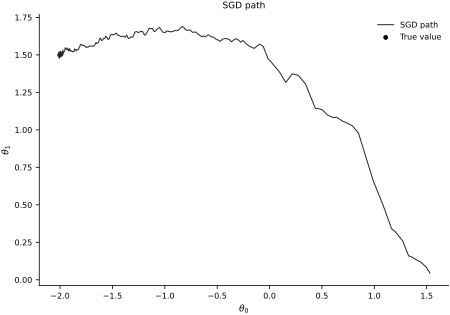

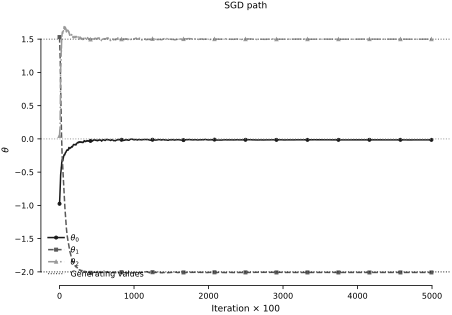

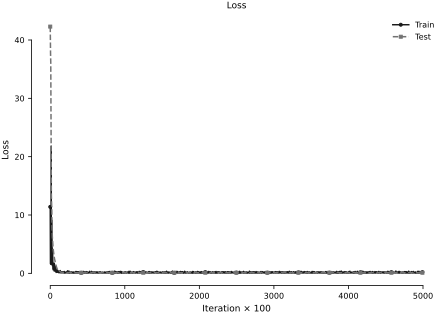

In [14]:
thetas = np.array(jax.tree_util.tree_leaves(path))

# 2D plot of the parameters evolution
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(thetas[:, 1], thetas[:, 2], color="0.15", lw=1.0, label="SGD path")
# Correct values
ax.scatter([-2], [1.5], marker="o", color="black", label="True value")
ax.set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", title="SGD path")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

# Parameters per iteration
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
markevery = max(1, thetas.shape[0] // 12)
ax.plot(thetas[:, 0], color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label=r"$\theta_0$")
ax.plot(thetas[:, 1], color="0.35", linestyle="--", marker="s", markevery=markevery, markersize=3, label=r"$\theta_1$")
ax.plot(thetas[:, 2], color="0.60", linestyle="-.", marker="^", markevery=markevery, markersize=3, label=r"$\theta_2$")
ax.axhline(-2, color="0.10", linestyle=":", lw=1, label="Generating values")
ax.axhline(1.5, color="0.35", linestyle=":", lw=1)
ax.axhline(0, color="0.60", linestyle=":", lw=1)
ax.set(xlabel="Iteration $\\times$ 100", ylabel=r"$\theta$", title="SGD path")
plt.legend(loc='best', frameon=False)
sns.despine(trim=True);

# The losses
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
markevery = max(1, len(losses) // 12)
ax.plot(losses, color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label="Train")
ax.plot(test_losses, color="0.45", linestyle="--", marker="s", markevery=markevery, markersize=3, label="Test")
ax.set(xlabel="Iteration $\\times$ 100", ylabel="Loss", title="Loss")
plt.legend(loc='best', frameon=False)
sns.despine(trim=True);
